# Booze ’R’ Us — City-Category Sales Forecast Analysis

**Client:** Booze ’R’ Us — projecting bottle sales for the coming year and
identifying city-specific alcohol categories that can guide inventory and
promotion decisions.

**Dataset:** city_category_month.parquet, which contains one observation for each alcohol category, month, and one of the ten highest-volume Iowa cities.

**Modeling target:** log1p_total_bottles, the log transformed net number of
bottles ordered by retailers. Modeling the log transformed target reduces the
influence of very large monthly orders while still allowing zero sales months
to remain in the data.

This notebook compares several linear regression models, evaluates their
performance using a time based holdout period, creates a 12 month forecast,
and summarizes the categories expected to have the highest bottle demand in
each major city.

# Step 1 — Load the Modeling Dataset

We load the completed city-category-month dataset created in the data build
notebook. The dataset includes total bottle sales, total liters, total sales
dollars, and date derived features for each city-category-month combination.

The monthly date is converted to a date type so that the data can be sorted
and divided into historical training and future testing periods correctly.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "/content/city_category_month.parquet"

model_df = pd.read_parquet(file_path)

# Make sure the monthly time variable is read as a date
model_df["month_start"] = pd.to_datetime(model_df["month_start"])

print("Dataset shape:", model_df.shape)
print("Date range:",
      model_df["month_start"].min().date(),
      "to",
      model_df["month_start"].max().date())

print("\nColumns:")
print(model_df.columns.tolist())

model_df.head()

Dataset shape: (28000, 10)
Date range: 2022-01-01 to 2026-08-01

Columns:
['store_city', 'category_name', 'month_start', 'total_bottles', 'total_liters', 'total_sales_dollars', 'year', 'month_number', 'time_index', 'log1p_total_bottles']


,store_city,category_name,month_start,total_bottles,total_liters,total_sales_dollars,year,month_number,time_index,log1p_total_bottles
0,ANKENY,100% AGAVE TEQUILA,2022-01-01,667.0,491.96,18621.92,2022,1,0,6.504288
1,ANKENY,100% AGAVE TEQUILA,2022-02-01,1856.0,1385.21,62033.51,2022,2,1,7.526718
2,ANKENY,100% AGAVE TEQUILA,2022-03-01,1283.0,922.21,36144.98,2022,3,2,7.157735
3,ANKENY,100% AGAVE TEQUILA,2022-04-01,2846.0,2756.69,75998.45,2022,4,3,7.954021
4,ANKENY,100% AGAVE TEQUILA,2022-05-01,2724.0,2842.08,69427.38,2022,5,4,7.910224


# Step 2 — Create a Time Based Train/Test Split

Because the goal is to predict future sales, we do not randomly split the
data. A random split could allow the model to train on later months while
testing on earlier months, which would not reflect a realistic forecasting
situation.

Instead, the final six months of available data are held out as the test set.
The model is trained using the earlier months and then asked to predict the
months it has not seen. This lets us evaluate how well each model performs on
future data.

In [2]:
# Hold out the final six months for testing
test_start = (
    model_df["month_start"].max()
    - pd.DateOffset(months=5)
)

train_df = model_df[
    model_df["month_start"] < test_start
].copy()

test_df = model_df[
    model_df["month_start"] >= test_start
].copy()

print("Training period:",
      train_df["month_start"].min().date(),
      "to",
      train_df["month_start"].max().date())

print("Test period:",
      test_df["month_start"].min().date(),
      "to",
      test_df["month_start"].max().date())

print("\nTraining rows:", f"{len(train_df):,}")
print("Test rows:", f"{len(test_df):,}")

Training period: 2022-01-01 to 2026-02-01
Test period: 2026-03-01 to 2026-08-01

Training rows: 25,000
Test rows: 3,000


# Step 3 — Baseline Linear Regression Model

The baseline model includes:
* time_index to capture an overall change in bottle sales over time
* month_number to capture recurring monthly or seasonal patterns
* store_city to account for different average sales levels across cities
* category_name to account for different average sales levels across alcohol categories

This model gives each city and category its own average level of sales, but it
does not yet allow a category’s relationship with sales to differ from one
city to another. It serves as a simple starting point for evaluating whether
more detailed city-specific modeling improves the forecast.

Model performance is evaluated with RMSE and MAE on both the log scale and the original bottle count scale. Lower values indicate better predictions.

In [3]:
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Baseline linear regression:
# city and category have their own average effects,
# but the model does not yet allow category preferences to differ by city.
baseline_formula = """
log1p_total_bottles
~ time_index
+ C(month_number)
+ C(store_city)
+ C(category_name)
"""

baseline_model = smf.ols(
    formula=baseline_formula,
    data=train_df
).fit()

# Predict the six held-out months
test_df = test_df.copy()

test_df["predicted_log_bottles_baseline"] = (
    baseline_model.predict(test_df)
)

# Convert log predictions back to bottle counts
test_df["predicted_bottles_baseline"] = np.maximum(
    np.expm1(test_df["predicted_log_bottles_baseline"]),
    0
)

# Evaluate on both log scale and original bottle scale
baseline_rmse_log = mean_squared_error(
    test_df["log1p_total_bottles"],
    test_df["predicted_log_bottles_baseline"]
) ** 0.5

baseline_mae_log = mean_absolute_error(
    test_df["log1p_total_bottles"],
    test_df["predicted_log_bottles_baseline"]
)

baseline_rmse_bottles = mean_squared_error(
    test_df["total_bottles"],
    test_df["predicted_bottles_baseline"]
) ** 0.5

baseline_mae_bottles = mean_absolute_error(
    test_df["total_bottles"],
    test_df["predicted_bottles_baseline"]
)

print("Baseline model test performance")
print(f"RMSE (log bottles): {baseline_rmse_log:.3f}")
print(f"MAE  (log bottles): {baseline_mae_log:.3f}")
print(f"RMSE (bottles):     {baseline_rmse_bottles:,.0f}")
print(f"MAE  (bottles):     {baseline_mae_bottles:,.0f}")

Baseline model test performance
RMSE (log bottles): 2.423
MAE  (log bottles): 1.396
RMSE (bottles):     3,717
MAE  (bottles):     1,269


# Step 4 — City-Specific Category Model

The second linear regression model adds an interaction between store_city
and category_name.

This allows the model to learn that the same alcohol category can have different expected sales patterns in different cities. For example, tequila
may be more important in Des Moines than in another major Iowa city, even
after accounting for each city’s overall sales volume.

Comparing this model with the baseline tests whether location-specific
category preferences improve the sales forecast.

In [4]:
# City-specific linear regression:
# Allows categories to have different expected sales patterns in each city.
city_category_formula = """
log1p_total_bottles
~ time_index
+ C(month_number)
+ C(store_city) * C(category_name)
"""

city_category_model = smf.ols(
    formula=city_category_formula,
    data=train_df
).fit()

# Predict the held-out months
test_df["predicted_log_bottles_city_category"] = (
    city_category_model.predict(test_df)
)

test_df["predicted_bottles_city_category"] = np.maximum(
    np.expm1(test_df["predicted_log_bottles_city_category"]),
    0
)

# Evaluate the city-specific model
city_category_rmse_log = mean_squared_error(
    test_df["log1p_total_bottles"],
    test_df["predicted_log_bottles_city_category"]
) ** 0.5

city_category_mae_log = mean_absolute_error(
    test_df["log1p_total_bottles"],
    test_df["predicted_log_bottles_city_category"]
)

city_category_rmse_bottles = mean_squared_error(
    test_df["total_bottles"],
    test_df["predicted_bottles_city_category"]
) ** 0.5

city_category_mae_bottles = mean_absolute_error(
    test_df["total_bottles"],
    test_df["predicted_bottles_city_category"]
)

model_comparison = pd.DataFrame({
    "model": [
        "Baseline: city + category",
        "City-specific: city × category"
    ],
    "RMSE_log": [
        baseline_rmse_log,
        city_category_rmse_log
    ],
    "MAE_log": [
        baseline_mae_log,
        city_category_mae_log
    ],
    "RMSE_bottles": [
        baseline_rmse_bottles,
        city_category_rmse_bottles
    ],
    "MAE_bottles": [
        baseline_mae_bottles,
        city_category_mae_bottles
    ]
})

model_comparison

,model,RMSE_log,MAE_log,RMSE_bottles,MAE_bottles
0,Baseline: city + category,2.423234,1.395547,3717.460803,1268.596088
1,City-specific: city × category,2.390733,1.277967,3286.391802,1044.853415


# Step 5 — Add Category-Specific Time Trends and Select a Model

The third model keeps the city-category interaction and adds a separate time
trend for each alcohol category.

This means the model can recognize that some categories may be growing or
declining over time differently from others. For example, one category may
have a gradual upward trend while another category remains stable or decreases.

We compare all three models using RMSE and MAE on the held out future months. The model with the lowest errors provides the best balance of accuracy and usefulness for Booze ’R’ Us’s city-specific forecasting question.

In [5]:
# Model C: city-specific category effects + category-specific time trends
trend_formula = """
log1p_total_bottles
~ time_index
+ C(month_number)
+ C(store_city) * C(category_name)
+ C(category_name):time_index
"""

trend_model = smf.ols(
    formula=trend_formula,
    data=train_df
).fit()

test_df["predicted_log_bottles_trend"] = trend_model.predict(test_df)

test_df["predicted_bottles_trend"] = np.maximum(
    np.expm1(test_df["predicted_log_bottles_trend"]),
    0
)

trend_rmse_log = mean_squared_error(
    test_df["log1p_total_bottles"],
    test_df["predicted_log_bottles_trend"]
) ** 0.5

trend_mae_log = mean_absolute_error(
    test_df["log1p_total_bottles"],
    test_df["predicted_log_bottles_trend"]
)

trend_rmse_bottles = mean_squared_error(
    test_df["total_bottles"],
    test_df["predicted_bottles_trend"]
) ** 0.5

trend_mae_bottles = mean_absolute_error(
    test_df["total_bottles"],
    test_df["predicted_bottles_trend"]
)

model_comparison.loc[len(model_comparison)] = [
    "City-specific + category trends",
    trend_rmse_log,
    trend_mae_log,
    trend_rmse_bottles,
    trend_mae_bottles
]

model_comparison

,model,RMSE_log,MAE_log,RMSE_bottles,MAE_bottles
0,Baseline: city + category,2.423234,1.395547,3717.460803,1268.596088
1,City-specific: city × category,2.390733,1.277967,3286.391802,1044.853415
2,City-specific + category trends,1.240586,0.768212,2977.369429,926.573148


# Step 6 — Refit the Selected Model and Forecast the Coming Year

After selecting the best performing model, we refit it using all available
historical data. Using the full history gives the final model the most information possible before generating future predictions.

We then create every combination of the ten cities, alcohol categories, and
the next twelve months. The selected linear regression model predicts
log1p_total_bottles for each future city-category-month combination, and the predictions are converted back into estimated bottle counts.

The forecast period is September 2026 through August 2027.

In [9]:
# Refit the selected model using all available historical data
final_model = smf.ols(
    formula=trend_formula,
    data=model_df
).fit()

# Create the 12 future months to forecast
last_month = model_df["month_start"].max()

future_months = pd.date_range(
    last_month + pd.offsets.MonthBegin(1),
    periods=12,
    freq="MS"
)

cities = sorted(model_df["store_city"].unique())
categories = sorted(model_df["category_name"].unique())

# Create every city-category-month combination for the coming year
future_df = pd.MultiIndex.from_product(
    [cities, categories, future_months],
    names=["store_city", "category_name", "month_start"]
).to_frame(index=False)

# Create the same calendar and trend features used for training
first_month = model_df["month_start"].min()

future_df["month_number"] = future_df["month_start"].dt.month

future_df["time_index"] = (
    (future_df["month_start"].dt.year - first_month.year) * 12
    + (future_df["month_start"].dt.month - first_month.month)
)

# Forecast bottles
future_df["predicted_log_bottles"] = final_model.predict(future_df)

future_df["predicted_bottles"] = np.maximum(
    np.expm1(future_df["predicted_log_bottles"]),
    0
)

print("Forecast period:",
      future_df["month_start"].min().date(),
      "to",
      future_df["month_start"].max().date())

future_df.head(15)

Forecast period: 2026-09-01 to 2027-08-01


,store_city,category_name,month_start,month_number,time_index,predicted_log_bottles,predicted_bottles
0,ANKENY,100% AGAVE TEQUILA,2026-09-01,9,56,8.083039,3238.062359
1,ANKENY,100% AGAVE TEQUILA,2026-10-01,10,57,8.253634,3840.560188
2,ANKENY,100% AGAVE TEQUILA,2026-11-01,11,58,8.403794,4462.970701
3,ANKENY,100% AGAVE TEQUILA,2026-12-01,12,59,8.578745,5316.428332
4,ANKENY,100% AGAVE TEQUILA,2027-01-01,1,60,7.991419,2954.487588
5,ANKENY,100% AGAVE TEQUILA,2027-02-01,2,61,8.002260,2986.702255
6,ANKENY,100% AGAVE TEQUILA,2027-03-01,3,62,8.074324,3209.954888
7,ANKENY,100% AGAVE TEQUILA,2027-04-01,4,63,8.140689,3430.282921
8,ANKENY,100% AGAVE TEQUILA,2027-05-01,5,64,8.139882,3427.514171
9,ANKENY,100% AGAVE TEQUILA,2027-06-01,6,65,8.176214,3554.366991


# Step 7 — Translate Forecasts Into Sales-Tactic Recommendations

A forecast is most useful to Booze ’R’ Us when it can be connected to an inventory or promotion decision. We total the predicted bottle sales across the next twelve months for each city-category combination and rank categories
within each city.

The resulting table shows:
* the forecast rank of each category within its city
* predicted bottles for the next twelve months
* the category’s share of the city’s predicted bottle volume
* actual bottle sales during the most recent twelve months
* the forecasted percentage change from the recent period

These results should be used to prioritize categories for city-specific inventory attention and promotions. They should not be interpreted as exact instructions to increase or decrease every order by the forecasted percentage.

In [10]:
# Most recent 12 months of actual sales: Sep. 2025 through Aug. 2026
last_observed_month = model_df["month_start"].max()

recent_actual_start = (
    last_observed_month
    - pd.DateOffset(months=11)
)

recent_actuals = (
    model_df[
        model_df["month_start"] >= recent_actual_start
    ]
    .groupby(
        ["store_city", "category_name"],
        as_index=False
    )
    .agg(
        actual_bottles_last_12m=("total_bottles", "sum")
    )
)

# Forecasted 12-month total: Sep. 2026 through Aug. 2027
annual_forecast = (
    future_df.groupby(
        ["store_city", "category_name"],
        as_index=False
    )
    .agg(
        predicted_bottles_next_12m=("predicted_bottles", "sum")
    )
)

# Combine actual recent sales with future forecasts
recommendation_table = annual_forecast.merge(
    recent_actuals,
    on=["store_city", "category_name"],
    how="left"
)

recommendation_table["forecast_change_bottles"] = (
    recommendation_table["predicted_bottles_next_12m"]
    - recommendation_table["actual_bottles_last_12m"]
)

# Avoid dividing by zero for categories with no recent sales
recommendation_table["forecast_change_percent"] = np.where(
    recommendation_table["actual_bottles_last_12m"] > 0,
    100
    * recommendation_table["forecast_change_bottles"]
    / recommendation_table["actual_bottles_last_12m"],
    np.nan
)

# Calculate each category's expected share of its city's forecasted volume
city_forecast_totals = (
    recommendation_table.groupby(
        "store_city",
        as_index=False
    )
    .agg(
        city_predicted_bottles_next_12m=(
            "predicted_bottles_next_12m",
            "sum"
        )
    )
)

recommendation_table = recommendation_table.merge(
    city_forecast_totals,
    on="store_city",
    how="left"
)

recommendation_table["forecast_share_of_city_percent"] = (
    100
    * recommendation_table["predicted_bottles_next_12m"]
    / recommendation_table["city_predicted_bottles_next_12m"]
)

# Rank categories by expected annual bottle demand within each city
recommendation_table["forecast_rank_in_city"] = (
    recommendation_table.groupby("store_city")[
        "predicted_bottles_next_12m"
    ]
    .rank(method="first", ascending=False)
)

# Show the five highest-demand forecasted categories in every city
top_forecasts_by_city = (
    recommendation_table[
        recommendation_table["forecast_rank_in_city"] <= 5
    ]
    .sort_values(["store_city", "forecast_rank_in_city"])
)

top_forecasts_by_city[
    [
        "store_city",
        "forecast_rank_in_city",
        "category_name",
        "predicted_bottles_next_12m",
        "forecast_share_of_city_percent",
        "actual_bottles_last_12m",
        "forecast_change_percent"
    ]
]

,store_city,forecast_rank_in_city,category_name,predicted_bottles_next_12m,forecast_share_of_city_percent,actual_bottles_last_12m,forecast_change_percent
11,ANKENY,1.0,AMERICAN VODKAS,179726.154926,21.264273,194965.0,-7.816195
48,ANKENY,2.0,WHISKEY LIQUEUR,120652.331111,14.274963,151983.0,-20.614588
43,ANKENY,3.0,STRAIGHT BOURBON WHISKIES,75089.556114,8.884210,87883.0,-14.557359
14,ANKENY,4.0,CANADIAN WHISKIES,65616.774635,7.763439,78665.0,-16.587079
0,ANKENY,5.0,100% AGAVE TEQUILA,44148.537983,5.223428,41018.0,7.632108
61,CEDAR RAPIDS,1.0,AMERICAN VODKAS,546335.715298,24.508045,582646.0,-6.231963
98,CEDAR RAPIDS,2.0,WHISKEY LIQUEUR,338616.037018,15.189959,379511.0,-10.775699
64,CEDAR RAPIDS,3.0,CANADIAN WHISKIES,164091.275217,7.360962,193368.0,-15.140419
93,CEDAR RAPIDS,4.0,STRAIGHT BOURBON WHISKIES,137289.661026,6.158670,156735.0,-12.406507
50,CEDAR RAPIDS,5.0,100% AGAVE TEQUILA,125612.599038,5.634849,119617.0,5.012330


# Step 8 — Evaluate the Holdout Forecast Visually

The holdout chart compares actual and predicted bottle totals across the ten
major cities for the six months not used to train the model.

This visual check complements RMSE and MAE by showing when the model performs well and when it misses important changes in overall demand. It is especially useful because a model can have reasonable average error metrics while still missing a large change in a particular month.

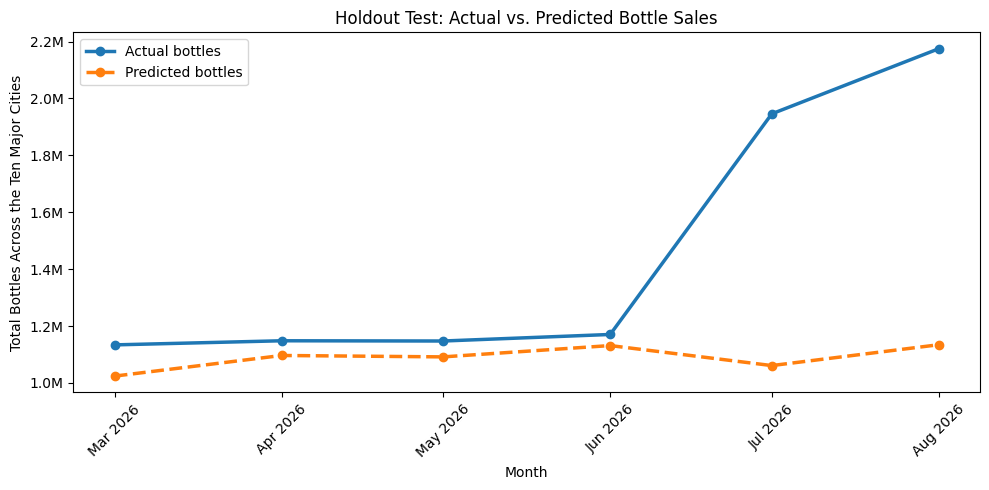

In [11]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

holdout_monthly = (
    test_df.groupby("month_start", as_index=False)
    .agg(
        actual_bottles=("total_bottles", "sum"),
        predicted_bottles=("predicted_bottles_trend", "sum")
    )
)

plt.figure(figsize=(10, 5))

plt.plot(
    holdout_monthly["month_start"],
    holdout_monthly["actual_bottles"],
    marker="o",
    linewidth=2.5,
    label="Actual bottles"
)

plt.plot(
    holdout_monthly["month_start"],
    holdout_monthly["predicted_bottles"],
    marker="o",
    linewidth=2.5,
    linestyle="--",
    label="Predicted bottles"
)

plt.title("Holdout Test: Actual vs. Predicted Bottle Sales")
plt.xlabel("Month")
plt.ylabel("Total Bottles Across the Ten Major Cities")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x / 1_000_000:.1f}M")
)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Step 9 — Investigate the Unusual July/August 2026 Increase

The holdout evaluation revealed a large increase in bottle orders during July and August 2026. To understand whether this was a normal seasonal pattern, we compare sales across the major cities and compare May through August across each available year.

The results show that the sharp June-to-July increase occurred in all ten cities and was unique to 2026. In the earlier years, July sales were generally flat or lower than June sales. This suggests that the jump may reflect a
change in retailer ordering behavior or data/reporting procedures rather than
a normal summer pattern.

Because the change was not present in the training data, the model could not
reasonably predict it in advance.

In [14]:
# Diagnose the July/August 2026 jump by city
diagnostic_months = pd.to_datetime([
    "2026-06-01",
    "2026-07-01",
    "2026-08-01"
])

city_month_actual = (
    model_df[model_df["month_start"].isin(diagnostic_months)]
    .groupby(["store_city", "month_start"], as_index=False)
    .agg(actual_bottles=("total_bottles", "sum"))
)

# Create a clean city-level comparison table
city_month_wide = (
    city_month_actual
    .pivot(index="store_city", columns="month_start", values="actual_bottles")
    .reindex(columns=diagnostic_months)
    .reset_index()
)

city_month_wide.columns = [
    "store_city",
    "june_2026_bottles",
    "july_2026_bottles",
    "august_2026_bottles"
]

city_month_wide["july_vs_june_percent"] = (
    (city_month_wide["july_2026_bottles"] /
     city_month_wide["june_2026_bottles"] - 1) * 100
)

city_month_wide["august_vs_july_percent"] = (
    (city_month_wide["august_2026_bottles"] /
     city_month_wide["july_2026_bottles"] - 1) * 100
)

city_month_wide["august_vs_june_percent"] = (
    (city_month_wide["august_2026_bottles"] /
     city_month_wide["june_2026_bottles"] - 1) * 100
)

city_month_wide = city_month_wide.sort_values(
    "august_vs_june_percent",
    ascending=False
)

display(
    city_month_wide.style.format({
        "june_2026_bottles": "{:,.0f}",
        "july_2026_bottles": "{:,.0f}",
        "august_2026_bottles": "{:,.0f}",
        "july_vs_june_percent": "{:+.1f}%",
        "august_vs_july_percent": "{:+.1f}%",
        "august_vs_june_percent": "{:+.1f}%"
    })
)

,store_city,june_2026_bottles,july_2026_bottles,august_2026_bottles,july_vs_june_percent,august_vs_july_percent,august_vs_june_percent
6,IOWA CITY,"63,376","115,128","175,780",+81.7%,+52.7%,+177.4%
5,DUBUQUE,"62,876","106,453","147,798",+69.3%,+38.8%,+135.1%
0,ANKENY,"57,789","102,500","127,670",+77.4%,+24.6%,+120.9%
9,WEST DES MOINES,"92,837","133,198","184,988",+43.5%,+38.9%,+99.3%
1,CEDAR RAPIDS,"169,826","284,453","323,508",+67.5%,+13.7%,+90.5%
8,WATERLOO,"79,679","144,641","150,804",+81.5%,+4.3%,+89.3%
2,COUNCIL BLUFFS,"90,328","179,376","168,638",+98.6%,-6.0%,+86.7%
3,DAVENPORT,"148,210","195,175","271,686",+31.7%,+39.2%,+83.3%
7,SIOUX CITY,"88,837","125,331","145,232",+41.1%,+15.9%,+63.5%
4,DES MOINES,"316,484","559,637","478,778",+76.8%,-14.4%,+51.3%


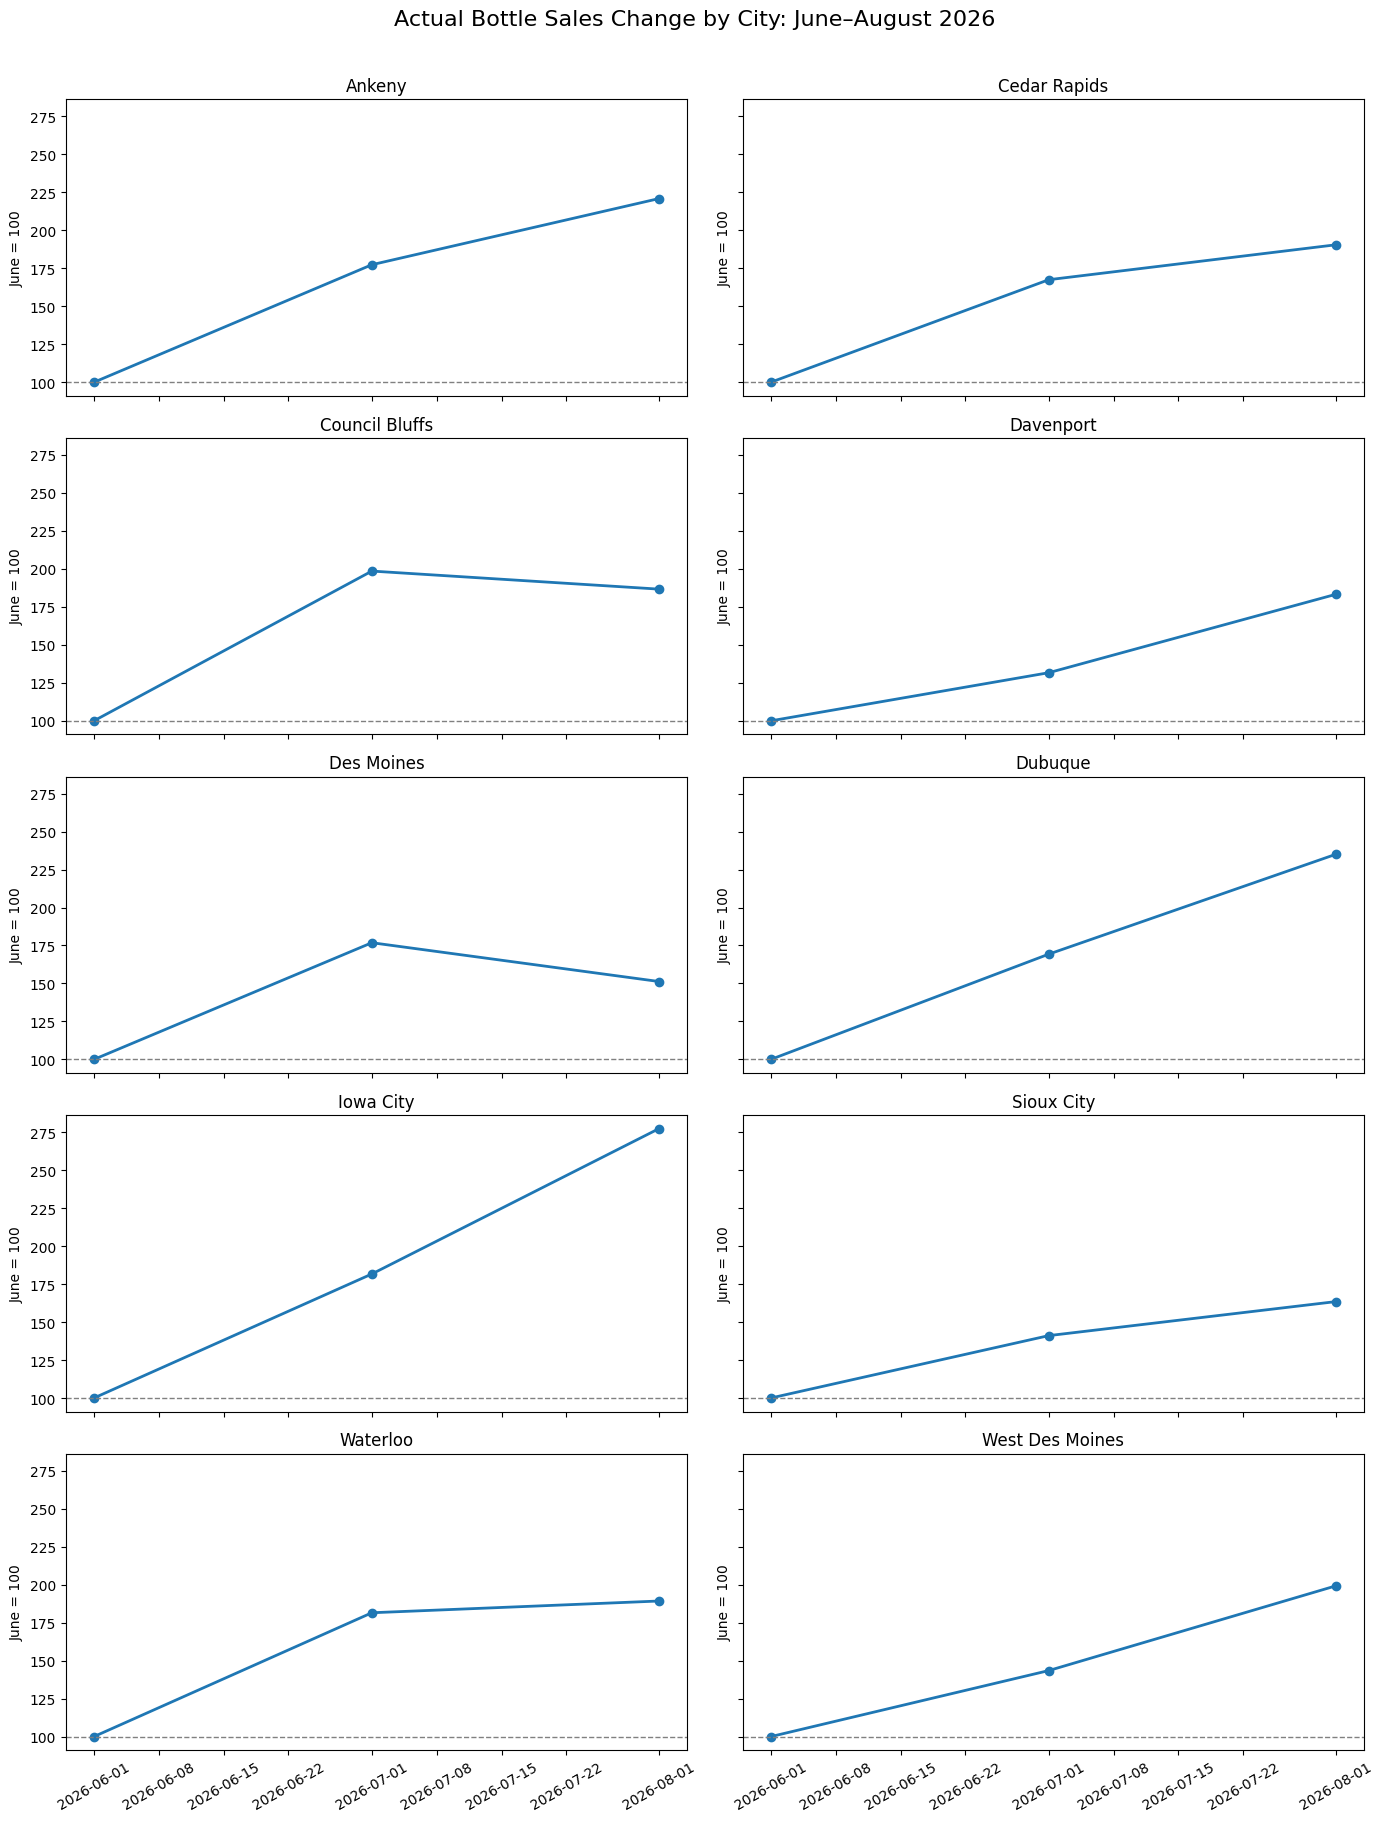

In [15]:
# Index each city's June sales to 100 for an easy percentage comparison
june_sales = (
    city_month_actual[
        city_month_actual["month_start"] == pd.Timestamp("2026-06-01")
    ][["store_city", "actual_bottles"]]
    .rename(columns={"actual_bottles": "june_bottles"})
)

city_month_indexed = city_month_actual.merge(
    june_sales,
    on="store_city",
    how="left"
)

city_month_indexed["sales_index_june_100"] = (
    city_month_indexed["actual_bottles"] /
    city_month_indexed["june_bottles"] * 100
)

# One small chart per city
cities = sorted(city_month_indexed["store_city"].unique())

fig, axes = plt.subplots(5, 2, figsize=(14, 18), sharex=True, sharey=True)
axes = axes.flatten()

for ax, city in zip(axes, cities):
    city_data = city_month_indexed[
        city_month_indexed["store_city"] == city
    ].sort_values("month_start")

    ax.plot(
        city_data["month_start"],
        city_data["sales_index_june_100"],
        marker="o",
        linewidth=2
    )
    ax.axhline(100, color="gray", linestyle="--", linewidth=1)
    ax.set_title(city.title())
    ax.set_ylabel("June = 100")
    ax.tick_params(axis="x", rotation=30)

for ax in axes[len(cities):]:
    ax.remove()

fig.suptitle(
    "Actual Bottle Sales Change by City: June–August 2026",
    fontsize=16,
    y=1.01
)

plt.tight_layout()
plt.show()

In [16]:
# Compare early-summer bottle sales across years for the ten major cities
summer_sales = (
    model_df[model_df["month_number"].isin([5, 6, 7, 8])]
    .groupby(["year", "month_number"], as_index=False)
    .agg(total_bottles=("total_bottles", "sum"))
)

summer_sales["month_name"] = summer_sales["month_number"].map({
    5: "May",
    6: "June",
    7: "July",
    8: "August"
})

# Table: compare June-to-July and July-to-August changes each year
summer_table = (
    summer_sales
    .pivot(index="year", columns="month_name", values="total_bottles")
    .reindex(columns=["May", "June", "July", "August"])
    .reset_index()
)

summer_table["july_vs_june_percent"] = (
    (summer_table["July"] / summer_table["June"] - 1) * 100
)

summer_table["august_vs_july_percent"] = (
    (summer_table["August"] / summer_table["July"] - 1) * 100
)

display(
    summer_table.style.format({
        "May": "{:,.0f}",
        "June": "{:,.0f}",
        "July": "{:,.0f}",
        "August": "{:,.0f}",
        "july_vs_june_percent": "{:+.1f}%",
        "august_vs_july_percent": "{:+.1f}%"
    })
)

month_name,year,May,June,July,August,july_vs_june_percent,august_vs_july_percent
0,2022,"1,217,981","1,262,069","1,082,595","1,354,625",-14.2%,+25.1%
1,2023,"1,280,438","1,344,308","1,147,141","1,294,130",-14.7%,+12.8%
2,2024,"1,242,510","1,210,312","1,211,017","1,213,062",+0.1%,+0.2%
3,2025,"1,165,750","1,222,278","1,147,585","1,157,953",-6.1%,+0.9%
4,2026,"1,147,227","1,170,242","1,945,892","2,174,882",+66.3%,+11.8%


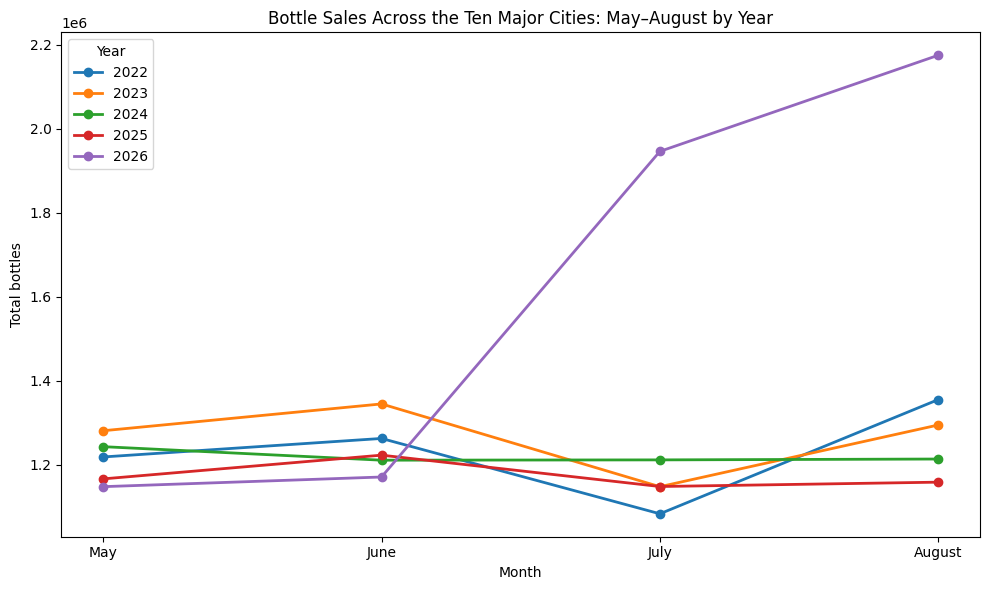

In [17]:
# Visual comparison of the May-to-August pattern across years
plt.figure(figsize=(10, 6))

for year in sorted(summer_sales["year"].unique()):
    year_data = summer_sales[
        summer_sales["year"] == year
    ].sort_values("month_number")

    plt.plot(
        year_data["month_name"],
        year_data["total_bottles"],
        marker="o",
        linewidth=2,
        label=str(year)
    )

plt.title("Bottle Sales Across the Ten Major Cities: May–August by Year")
plt.xlabel("Month")
plt.ylabel("Total bottles")
plt.legend(title="Year")
plt.tight_layout()
plt.show()